# Assignment 3: Linear Models

In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
    - A model is linear when it has parameters that have a linear relationship. This is through equations that show coefficients of certain parameters that cause them to have a linear relationship. This is often seen in an equation like y=mx+b.
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
   - The coefficient represents the difference between the predicted value and the baseline category that is usually omitted to show the weights of the parameters, not including the baseline.
3. Can linear regression be used for classification? Explain why, or why not.
   - Linear regression can be used for classification but it is not the most ideal way to do it. It will work if you set a threshold for the model, but the predictions or coefficients can throw it off since they are not always meant to define the probabilities of classes.
4. What are signs that your linear model is over-fitting?
   - You can tell if a linear model is over-fitting if there is not much flexibility because it is trained too well on the training data and does not adapt well to the testing data. This can be seen if you check these values, seeing how the model's error is for the training data compared to the testing data.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
   - Multi-colinearity is when multiple variables are very highly correlated, to the point where you can not always tell which is which, and the two-stage least squares technique allows us to isolate one of the variables that is problematic to see which is the cause. Once you isolate them, you can see which trend is not correlated with the other, then use linear regressions on the cleaned version of the predictors.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis? 
   - In order to incorporate nonlinear relationships, the features will need to be transformed in some way to represent them. This means that they must be expanded or transformed in some other way. This can be done through increasing the powers of the variables to get a better representation of the trend, or using the log operations.
7. What is the interpretation of the slope coefficient in a linear regression?
   - The slope coefficient of a linear regression indicates the correlation between the variables x and y. If positive, there is a positive correlation between the two variables. If negative, there is a negative correlation. It is like a normal slope, representing how much x changes with y.
8. Compare the train/test split and $k$-fold cross validation.
   - The train/test split sets aside part of the data to create a training model that you will then use on your testing data. Usually, this is something like 80% being used to train the model, which is then applied to the other 20%. On the other hand, k-fold cross validation does this in smaller segments. In k-fold cross validation, the data is randomly split into *k* number of groups, which are then used to train the model multiple times, allowing each group to be the test set once. 
9.  How is the $k$ in $k$-fold cross validation typically selected?
    - k is usually a value that splits the data into equal parts while maintaining a balance of variance and bias. There are standard values people usually find to fit well, like 5 or 10, but sometimes k values must be tested to see if they fit it well. It is usually the value that is statistically the most representative of the whole dataset. 

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [129]:
q1 = pd.read_csv("./data/Q1_clean.csv")
q1 = q1.rename(columns = {'Review Scores Rating': 'score', "Price": "price", "Neighbourhood ": "borough"})
q1['log_price'] = np.log(q1['price'])
q1.head()

,price,score,borough,Property Type,Room Type,log_price
0,549,96.0,Manhattan,Apartment,Private room,6.308098
1,149,100.0,Brooklyn,Apartment,Entire home/apt,5.003946
2,250,100.0,Manhattan,Apartment,Entire home/apt,5.521461
3,90,94.0,Brooklyn,Apartment,Private room,4.499810
4,270,90.0,Manhattan,Apartment,Entire home/apt,5.598422


In [130]:
# part 1
avg_q1 = q1.groupby('borough')[["price", "score"]].mean()
avg_q1

,price,score
borough,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhattan is the most expensive borough on average.

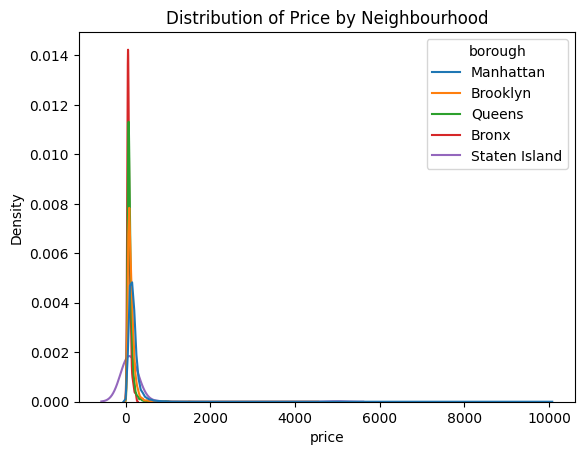

In [131]:
sns.kdeplot(q1, x='price', hue='borough', common_norm = False)
# For my plots, I added common_norm = False so that the values would be presented in a more accurate scale and the number of 
# observations they each had didn't impact their distributions against the others.
plt.title("Distribution of Price by Neighbourhood")
plt.show()

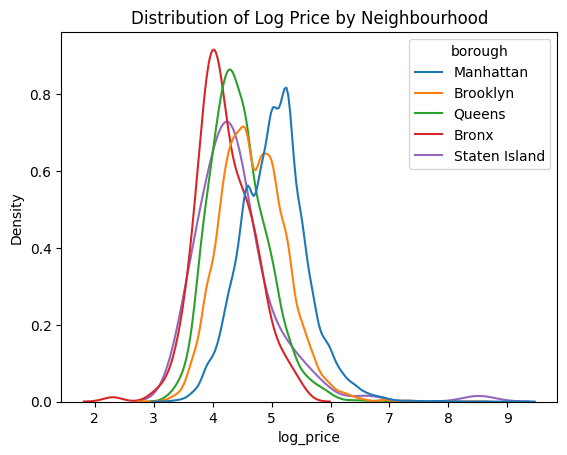

In [132]:
sns.kdeplot(q1, x='log_price', hue= 'borough', common_norm = False)
plt.title("Distribution of Log Price by Neighbourhood")
plt.show()

In [133]:
# part 2

x = pd.get_dummies(q1['borough'], dtype='int', drop_first=True)
y = q1['price']

model = LinearRegression().fit(x, y)

print("Intercept:", model.intercept_)
pd.DataFrame({'variable': model.feature_names_in_, 'coefficient': model.coef_})


Intercept: 75.27649769584602


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


I dropped the first category. The estimated coefficients are the differences of that given category from the intercept in price. So for example, the estimated coefficient of Brooklyn is the intercept subtracted from the conditional mean of Brooklyn.

In [134]:
# part 3 

x_3 = q1[['score']]
y = q1['price']

model_3 = LinearRegression(fit_intercept=True)
model_3.fit(x_3,y)

print("Intercept:", model_3.intercept_)
print('Score slope:', model_3.coef_[0])

Intercept: 60.87839065712386
Score slope: 1.020826602267473


The intercept represents the estimated price, and the slope coefficient represents how much the price increases as the score increases (rate of change). This means that in this model, the average price is $60.88 per night, with the price increasing $1.02 as the score increases.

In [135]:
# part 4

x_cat = pd.get_dummies(q1['borough'], drop_first=True)
x_num = q1[['score']]
x_4 = pd.concat([x_num, x_cat], axis=1)

y = q1['price']

model_4 = LinearRegression(fit_intercept=True)
model_4.fit(x_4,y)

print("Intercept:", model_4.intercept_)
print('Slope Coefficient:', model_4.coef_[0])
pd.DataFrame({'variable:': model_4.feature_names_in_[1:],'coefficient': model_4.coef_[1:]})

Intercept: -23.81256101167307
Slope Coefficient: 1.0811164834598521


,variable:,coefficient
0,Brooklyn,51.704240
1,Manhattan,108.228737
2,Queens,21.694600
3,Staten Island,71.766552


The slope coefficient slightly increased to 1.08, changing by about $0.06. The neighborhood averages decreased because it positively correlated with the price, so we now know that the scores are what effected the change more than the neighbourhoods.

In [136]:
# part 5

x_nbh_dummies = pd.get_dummies(q1['borough'], drop_first=False)
X_interactions = x_nbh_dummies.mul(q1['score'], axis=0)
y = q1['price']

model_5 = LinearRegression(fit_intercept=True)
model_5.fit(X_interactions,y)

print("Intercept:", model_5.intercept_)
pd.DataFrame({'neighborhood': X_interactions.columns, 'slope coefs': model_5.coef_})

Intercept: 55.11825364116282


,neighborhood,slope coefs
0,Bronx,0.222718
1,Brooklyn,0.790947
2,Manhattan,1.399376
3,Queens,0.456451
4,Staten Island,0.682444


In [137]:
# part 6 

from sklearn.model_selection import cross_val_score

model_list = [model_3, model_4, model_5]
x_vars = [x_3, x_4, X_interactions]

cv_scores_mean = []

for i in range(len(model_list)):
    model = model_list[i]
    x_var = x_vars[i]
    
    cv_scores = cross_val_score(model, x_var, y, cv=10, scoring="neg_mean_squared_error")
    cv_scores_mean.append(-cv_scores.mean())

best_model_index = cv_scores_mean.index(min(cv_scores_mean))

model_choices = ['Model 3', 'Model 4', 'Model 5']

print('The best model from using cross validation is', model_choices[best_model_index], 'with the value of', cv_scores_mean[best_model_index])

The best model from using cross validation is Model 5 with the value of 21068.84628866803


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [138]:
# part 1

cars = pd.read_csv('./data/cars_hw.csv')

print(cars.isna().sum())

cars = cars.rename(columns = {'Price':'price', 'Make_Year':'year', 'Body_Type':'body', 'Seating_Capacity':'seatcap'})
cars.head()

Unnamed: 0           0
Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
dtype: int64


,Unnamed: 0,Make,year,Color,body,Mileage_Run,No_of_Owners,seatcap,Fuel_Type,Transmission,Transmission_Type,price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [139]:
cars['price'].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: price, dtype: float64

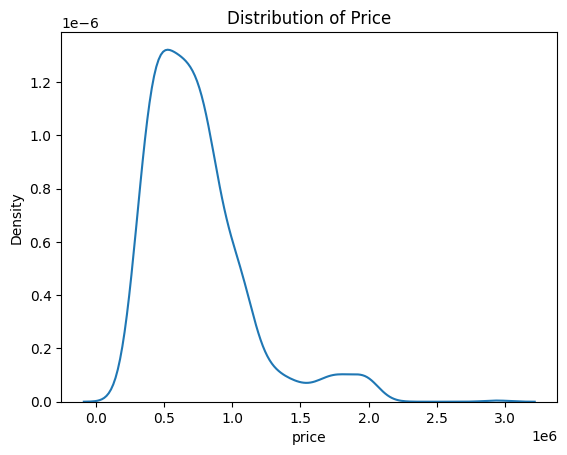

In [140]:
kde_price = sns.kdeplot(cars, x='price', common_norm=False)
plt.title('Distribution of Price')
plt.show()

In [141]:
price_sum = cars.groupby('body')['price'].describe()
print(price_sum)

           count          mean            std       min       25%        50%  \
body                                                                           
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
body                             
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


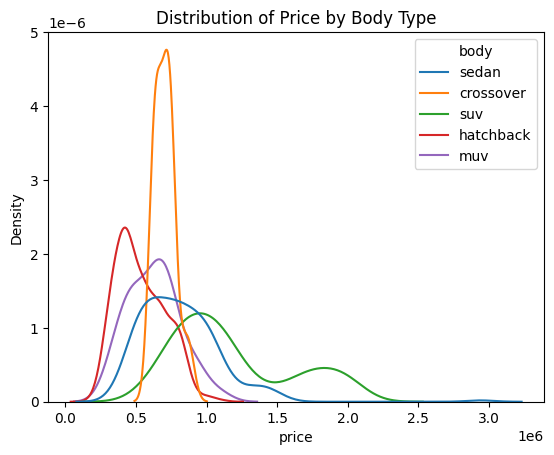

In [142]:
kde_group = sns.kdeplot(cars, x='price', hue='body', common_norm=False)
plt.title("Distribution of Price by Body Type")
plt.show()

Sedans are the most expensive car types and SUVs have the most variance.

In [143]:
# part 2

x = cars[['seatcap']]
y = cars['price']

model = LinearRegression(fit_intercept=True)
model.fit(x,y)

print("Intercept:", model.intercept_)
print('Slope Coefficient:', model.coef_[0])

Intercept: 439032.0141018268
Slope Coefficient: 59267.9980367217


As the seating capacity in the car increases by one seat, the price increases by about 59268 Indian rupees.

In [144]:
x = pd.get_dummies(cars['seatcap'], drop_first=True)
y = cars['price']

model = LinearRegression(fit_intercept=True)
model.fit(x,y)

print("Intercept:", model.intercept_)
print('Slope Coefficient:', model.coef_[0])
pd.DataFrame({'Seats:' : x.columns, 'coefs:':model.coef_})

Intercept: 188000.00000000396
Slope Coefficient: 546483.8709677377


,Seats:,coefs:
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


In [145]:
# part 3

cars['age'] = 2026 - cars['year']
cars.head()

,Unnamed: 0,Make,year,Color,body,Mileage_Run,No_of_Owners,seatcap,Fuel_Type,Transmission,Transmission_Type,price,age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [146]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

x = cars[['age']]
y = cars['price']

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

degrees = range(1, 11)
cv_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    x_poly = poly.fit_transform(x)
    
    model = LinearRegression(fit_intercept=True)
    
    scores = cross_val_score(model, x_poly, y, cv=kfold, scoring='r2')
    cv_scores.append(scores.mean())
    
    print(f"Degree {d}:", scores.mean())

best_degree = degrees[np.argmax(cv_scores)]
print("Optimal number of powers of Age:", best_degree)

Degree 1: 0.269025458006596
Degree 2: 0.2676569329091799
Degree 3: 0.2724501514283449
Degree 4: 0.2763778668548632
Degree 5: 0.28299078664958216
Degree 6: 0.28135340955391025
Degree 7: 0.2864168576522398
Degree 8: 0.28375851389237267
Degree 9: 0.2836797532726837
Degree 10: 0.28572205551428614
Optimal number of powers of Age: 7


<function matplotlib.pyplot.show(close=None, block=None)>

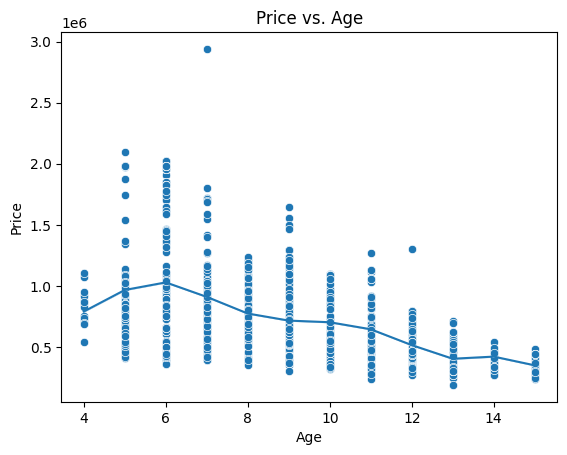

In [147]:
# part 4

x = cars[['age']]
y = cars['price']

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
x_poly = poly.fit_transform(x)

model = LinearRegression()
model.fit(x_poly, y)

y_pred = model.predict(x_poly)

sort_index = np.argsort(cars['age'])
sort_age = cars['age'].iloc[sort_index]
sort_price = cars['price'].iloc[sort_index]
sort_price_pred = y_pred[sort_index]

sns.scatterplot(x=cars['age'], y=y)
sns.lineplot(x=sort_age, y=sort_price_pred)
plt.title("Price vs. Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [148]:
heart = pd.read_csv('./data/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [149]:
heart['transplant'].value_counts()

transplant
treatment    69
control      34
Name: count, dtype: int64

In [150]:
# part 1

transplant_count = heart['transplant'].value_counts()

survivor_count = heart.groupby(heart['transplant'])['y'].sum()

control_prop = survivor_count['control']/transplant_count['control']
treatment_prop = survivor_count['treatment']/transplant_count['treatment']

ate = treatment_prop - control_prop

print('Control Group Proportion:', control_prop)
print('Treatment Group Proportion:', treatment_prop)
print('ATE on three year survival:', ate)

Control Group Proportion: 0.11764705882352941
Treatment Group Proportion: 0.34782608695652173
ATE on three year survival: 0.23017902813299232


In [151]:
# part 2

heart['transplant'] = heart['transplant'].map({'control':0, 'treatment':1})

x = heart[['transplant']]
y = heart['y']

model_tran = LinearRegression()
model_tran = model_tran.fit(x,y)

print('Model Intercept:', model_tran.intercept_)
df_transplant = pd.DataFrame({'var': model_tran.feature_names_in_, 'coef': model_tran.coef_})
df_transplant

Model Intercept: 0.11764705882352941


,var,coef
0,transplant,0.230179


The values are the same for part 1 and part 2.

In [152]:
# part 3

x_ta = heart[['transplant', 'age']]
y = heart['y']

model_ta = LinearRegression()
model_ta = model_ta.fit(x_ta,y)

print('Intercept:', model_ta.intercept_)
print('Treatment coef:', model_ta.coef_[0])
print('Age coef:', model_ta.coef_[1])

Intercept: 0.7019569721740948
Treatment coef: 0.2647016865036749
Age coef: -0.013607217160218645


The ceofficient increases when you control for age. The intercept represents a predicted probability of survival for a control patient when they are at the age of 0. 

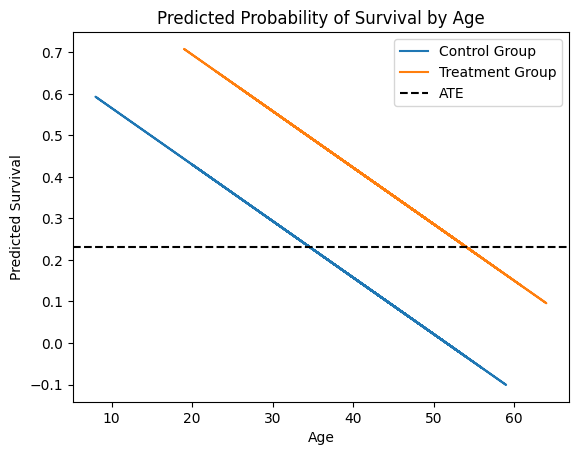

In [153]:
heart['pred_survival_ta'] = model_ta.predict(x_ta)

control = heart[heart['transplant'] == 0]

treat = heart[heart['transplant'] == 1]

plt.plot(control['age'], control['pred_survival_ta'], label='Control Group')
plt.plot(treat['age'], treat['pred_survival_ta'], label='Treatment Group')
plt.axhline(y=ate, linestyle='--', color='black', label='ATE')

plt.title('Predicted Probability of Survival by Age')
plt.xlabel('Age')
plt.ylabel('Predicted Survival')
plt.legend()
plt.show()

The ATE is underestimating for all of the ages since the difference between the two groups (control and treatment/transplant) is constant and greater than the ATE, which is roughly 0.23 compared to the 0.25 or so that we see between the two groups.

In [154]:
# part 4 - Now, include `transplant`, `age`, and `transplant * age`
#  as controls. Repeat your analysis from part 3. 
# How does allowing age and transplant to interact 
# change your predictions? 
# What pattern do you notice?

heart['trans_x_age'] = heart['transplant']* heart['age']

x_multiply = heart[['transplant', 'age', 'trans_x_age']]
y = heart['y']

model_multiply = LinearRegression()
model_multiply = model_multiply.fit(x_multiply,y)

print('Intercept:', model_multiply.intercept_)
print('Treatment coef:', model_multiply.coef_[0])
print('Age coef:', model_multiply.coef_[1])
print('Transplant times Age coef:', model_multiply.coef_[2])



Intercept: 0.3548651752994586
Treatment coef: 0.9077513885685895
Age coef: -0.005524257506973697
Transplant times Age coef: -0.014590638256855276


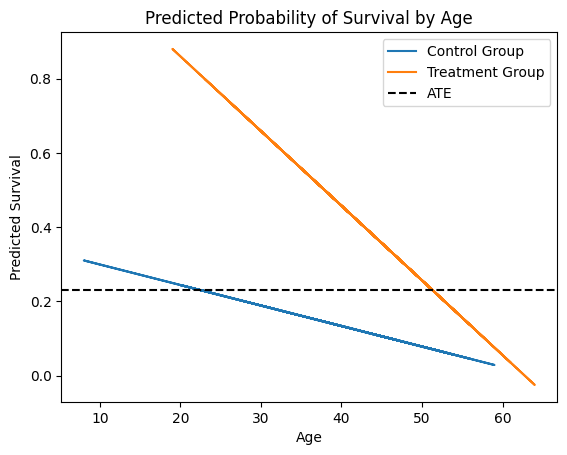

In [155]:
heart['pred_survival_txa'] = model_multiply.predict(x_multiply)

control = heart[heart['transplant'] == 0]

treat = heart[heart['transplant'] == 1]

plt.plot(control['age'], control['pred_survival_txa'], label='Control Group')
plt.plot(treat['age'], treat['pred_survival_txa'], label='Treatment Group')
plt.axhline(y=ate, linestyle='--', color='black', label='ATE')

plt.title('Predicted Probability of Survival by Age')
plt.xlabel('Age')
plt.ylabel('Predicted Survival')
plt.legend()
plt.show()

By allowing age and transplant to interact, we still see a decline, but with the treatment group increasing their rate of change and the control group's decreasing. Now the ATE is underestimating the effects for the younger individuals while overestimating for the older ones. 

In [156]:
# part 5

from sklearn.model_selection import cross_val_score

model_list = [model_tran, model_ta, model_multiply]
x_vars = [x, x_ta, x_multiply]

cv_scores_mean = []

for i in range(len(model_list)):
    model = model_list[i]
    x_var = x_vars[i]
    
    cv_scores = cross_val_score(model, x_var, y, cv=10, scoring="neg_mean_squared_error")
    cv_scores_mean.append(-cv_scores.mean())


print('Model Transplant:', cv_scores_mean[0])
print('Model Transplant and Age:', cv_scores_mean[1])
print('Model Interaction:', cv_scores_mean[2])

Model Transplant: 0.20970277289824915
Model Transplant and Age: 0.1992280604923232
Model Interaction: 0.19609811380122735


The model with the treatment, age, and the interaction between the two is the best because it has the lowest error. 

Part 6

I would be concerned in using a model like this because it is susceptible to overfitting to the data we test it on. Since this is a life-altering medical decision, I think that basing a decision of whether or not to give someone a transplant should be done on a better model or atleast one with an extremely low error, more than the 19.6% or so that we got above. 